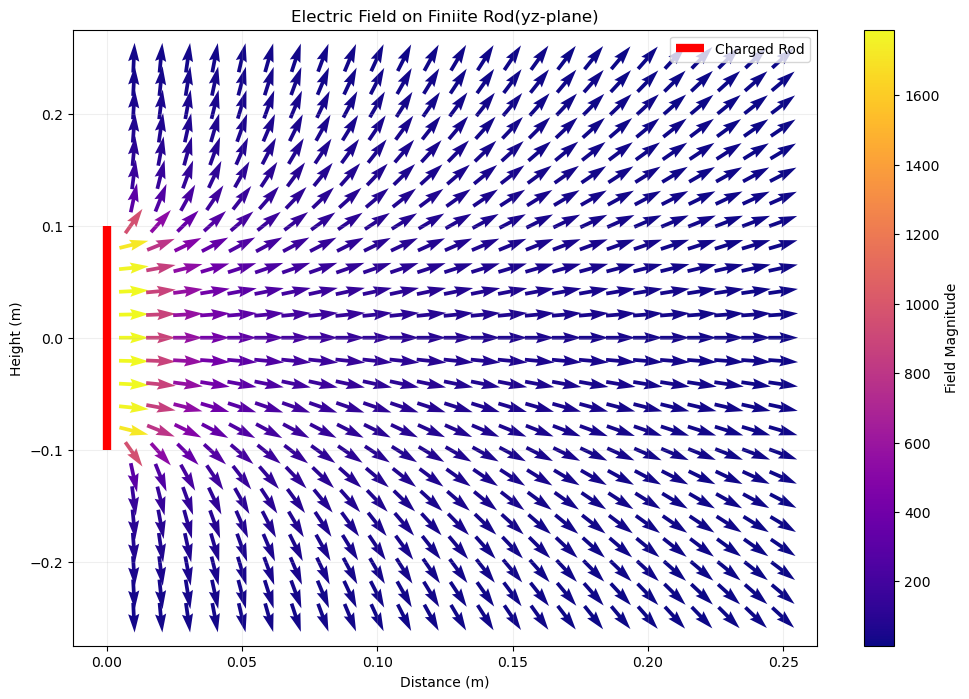

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid

#Problem 1

#Paremters
k_coulomb = 8.99e9 #(Nm^2/C^2)
lam = 1e-9 #(C/m)
L = 0.20 #(m)

# Electric Field of Finite Rod on Z-axis
def calculate_electric_field(y_obs, z_obs, L=L, lam=lam, n_segments=500):
    z_prime = np.linspace(-L/2,L/2, n_segments)

    r = np.sqrt(y_obs**2 + (z_obs - z_prime)**2)

    integrand_Ey = y_obs / r**3
    integrand_Ez = (z_obs - z_prime) / r**3

    Ey = k_coulomb * lam * trapezoid(integrand_Ey, z_prime)
    Ez = k_coulomb * lam * trapezoid(integrand_Ez, z_prime)

    return Ey, Ez

# Forming a Grid for YZ-plane
y_range = np.linspace(0.01, 0.25, 25)
z_range = np.linspace(-0.25, 0.25, 25)
Y, Z = np.meshgrid(y_range, z_range)


Ey_map = np.zeros_like(Y)
Ez_map = np.zeros_like(Z)
E_mag = np.zeros_like(Y)

# Calculating electric field at various points
for i in range((Z.shape[0])):
    for j in range((Y.shape[1])):
        Ey, Ez = calculate_electric_field(Y[i, j], Z[i, j])
        Ey_map[i, j] = Ey
        Ez_map[i, j] = Ez
        E_mag[i, j] = np.sqrt(Ey**2 + Ez**2)

# Initializing vectors
Ey_vec = Ey_map / E_mag
Ez_vec = Ez_map / E_mag


#Plotting
plt.figure(figsize=(12,8))

q = plt.quiver(Y, Z, Ey_vec, Ez_vec, E_mag, #Quiver Plot
               cmap='plasma',
               scale=25,
               width=0.005,
               pivot='mid')
               
plt.vlines(0, -L/2, L/2, color='red', linewidth=6, label ='Charged Rod')
plt.colorbar(q, label = 'Field Magnitude')
plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.title("Electric Field on Finiite Rod(yz-plane)")
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()


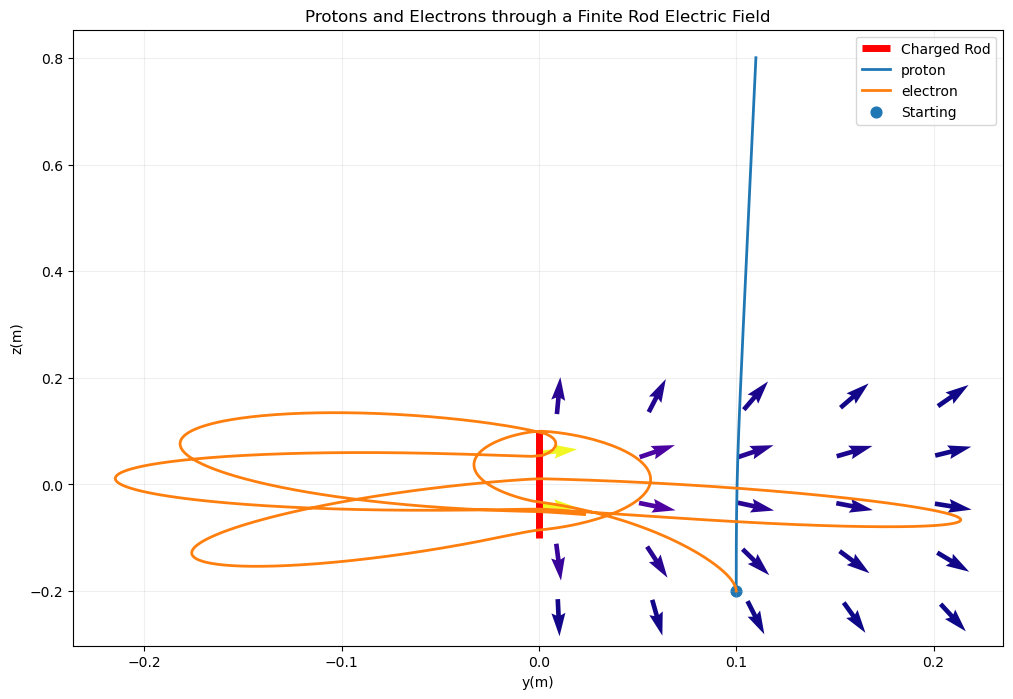

In [2]:
#Task 2
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# Particle values
electron_c = 1.602e-19 # (C)
mass_p = 1.673e-27  # (kg)
mass_e = 9.109e-31 # (kg)

def calculate_particle_velocity(t, state, q, m):
    y, z, vy, vz = state
# Obtaining a electric field at current position
    Ey, Ez = calculate_electric_field(y,z)

    ay = q * Ey / m
    az = q * Ez / m

    return [vy, vz, ay, az]

#Initial Parameters
y_theta = 0.10
z_theta = -0.20
vy0 = 0.0
vz0 = 5.0e5

state0=[y_theta, z_theta, vy0, vz0]

# Setting values for time(how long and time step)
t_max = 2.0e-6
t_span = (0, t_max)
t_eval = np.linspace(0, t_max, 1500)

# Calculating for proton and electron
sol_p = solve_ivp(calculate_particle_velocity, t_span, state0, args=(+electron_c, mass_p), t_eval=t_eval, rtol=1e-8)

sol_e = solve_ivp(calculate_particle_velocity, t_span, state0, args=(-electron_c ,mass_e),t_eval=t_eval, rtol=1e-8)

# Intializing vectors
Ey_unit = Ey_map / E_mag
Ez_unit = Ez_map / E_mag

plt.figure(figsize=(12,8))

s = slice(None, None, 5)

q = plt.quiver(Y[s,s], Z[s,s], Ey_vec[s,s], Ez_vec[s,s], E_mag[s,s],
               cmap='plasma',
               scale=25,
               width=0.005,
               pivot='mid')
               
# Forming rod
plt.vlines(0, -L/2, L/2, color='red', linewidth=5, label='Charged Rod')
plt.plot(sol_p.y[0], sol_p.y[1], label = 'proton', linewidth=2) # Proton trajectory
plt.plot(sol_e.y[0], sol_e.y[1], label = 'electron', linewidth=2) # electron trajectory

plt.scatter(y_theta, z_theta, marker= 'o', s=60, label='Starting')
plt.xlabel('y(m)')
plt.ylabel('z(m)')
plt.title('Protons and Electrons through a Finite Rod Electric Field')
plt.grid(True,alpha=0.2)
plt.legend()
plt.show()

#Question Response : The mass of an electron is significantly less than a proton, meaning that they have different accelerations with electrons have a higher acceleration, making them able to change direction quicker than protons and that's why it's more curved than the proton path.

In [3]:
#Task 3
#Integration point
integrate_p = 700

# Point charge
y = 5.0 #(m)
z = 0.0 #(m)

Ey_num, Ez_num = calculate_electric_field(y, z, n_segments=integrate_p)

# Charge of rod
Q_total = lam * L

# Guessing for point charge
Ey_point = k_coulomb * Q_total / y**2

percent_error_point= abs(Ey_num - Ey_point) / abs(Ey_point) * 100

print(" Point Charge Limit")
print(f"Numerical Ey at y = {y} m: {Ey_num:.6e} N/C")
print(f"Point Charge Ey appro.: {Ey_point:.6e} N/C")
print(f"% Error: {percent_error_point:.6f}%")
print()

# Infinite limit for line
y_close = 0.001
z_close = 0.0

Ey_close, Ez_close = calculate_electric_field(y_close, z_close, n_segments=integrate_p)

# Guessing for infinite wire
Ey_line = (k_coulomb * 2 * lam) / y_close

percent_error_line = abs(Ey_close - Ey_line)/ abs(Ey_line) * 100

print(" Infinite Line Limit ")
print(f"Numerical Ey at y = {y_close} m, z = 0: {Ey_close:.6e} N/C")
print(f"Infinite Wire Ey appro.: {Ey_line:.6e} N/C")
print(f"% error: {percent_error_line:.6f}%")




 Point Charge Limit
Numerical Ey at y = 5.0 m: 7.190562e-02 N/C
Point Charge Ey appro.: 7.192000e-02 N/C
% Error: 0.019994%

 Infinite Line Limit 
Numerical Ey at y = 0.001 m, z = 0: 1.797910e+04 N/C
Infinite Wire Ey appro.: 1.798000e+04 N/C
% error: 0.005000%


In [4]:
# Task 4
# Question 1 Response : It's sufficient because due to the fact of it being 2D, the electric field is only determined by distance from the rod, as opposed to its position about the rod. That means rotating the plane wouldn't affect the electric field.
# Question 2 Response : Getting towards aroudn 700 segments

Minimum safe velocity : 1.090361e+05 m/s


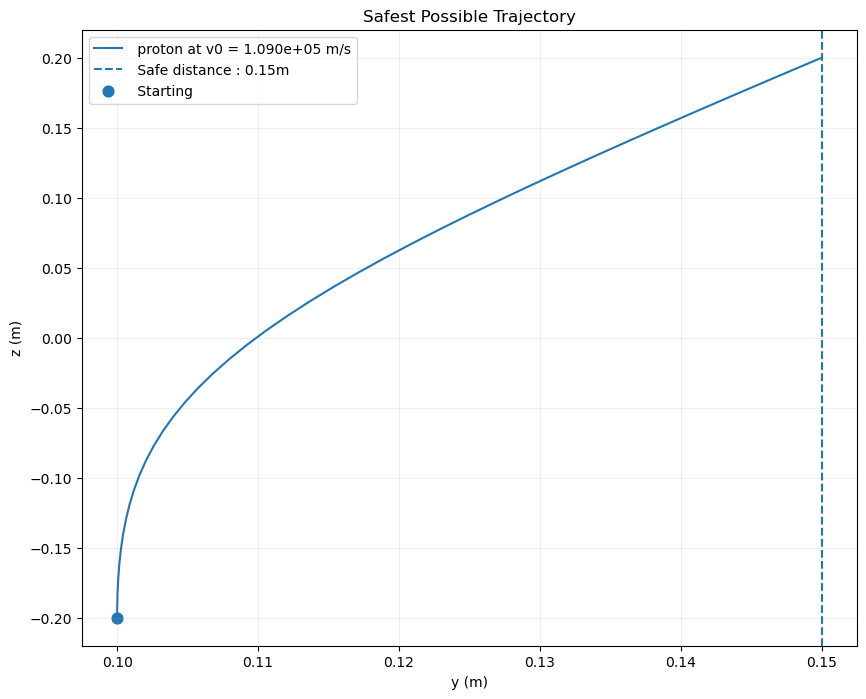

In [6]:
#Task 5

def calculate_proton_velocity(t, state):
    y, z, vy, vz = state

    Ey, Ez = calculate_electric_field(y, z, n_segments=1000)

    ay = electron_c * Ey / mass_p
    az = electron_c * Ez / mass_p

    return[vy, vz, ay, az]

# Hypothesizing events( if proton goes farther than 0.15 m and if protons surpasses the rod) 
def far_event(t, state):
    y, z, vy, vz = state
    return y - 0.15

far_event.terminal = True
far_event.direction = 1

def passed_rod(t, state):
    y, z, vy, vz = state
    return z - 0.20

passed_rod.terminal = True
passed_rod.direction = 1

# Testing for stable velocity value
def stable_proton_velocity(vel):
    state0 = [0.10, -0.20, 0.0, vel]

    sol = solve_ivp(calculate_proton_velocity, (0, 5e-5), state0, events=[far_event, passed_rod],max_step = 1.e-7, rtol=1e-7)

    limit = len(sol.t_events[0]) > 0
    rod_passed = len(sol.t_events[1]) > 0

    return (not limit) and rod_passed, sol


# Calulating the most safest stable initial velocity
low_vel = 1.0e5
high_vel = 2.0e5

# Stablizing upper limit
safe_upper, _ = stable_proton_velocity(high_vel)

while not safe_upper:
    high_vel *= 1.5
    safe_upper, _ = safe_proton(high_vel)

for _ in range(40):
    mid_vel = 0.5 * (low_vel+high_vel)
    safe_mid, _ = stable_proton_velocity(mid_vel)

    if safe_mid:
        high_vel = mid_vel
    else :
        low_vel = mid_vel

min_vel = high_vel
print(f"Minimum safe velocity : {min_vel:.6e} m/s")

safe, min_sol = stable_proton_velocity(min_vel)

plt.figure(figsize=(10,8))
plt.plot(min_sol.y[0], min_sol.y[1], label=f' proton at v0 = {min_vel:.3e} m/s')
plt.axvline(0.15, linestyle= '--', label = ' Safe distance : 0.15m ' )
plt.scatter(0.10,-0.20,s=60, label =' Starting ')

plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.title('Safest Possible Trajectory')
plt.legend()
plt.grid(True, alpha = 0.2)
plt.show()
    

In [ ]:
#Task 6
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, solve_ivp


# Constants
k_coulomb = 8.99e9
L = 0.20
electron_c= 1.602e-19
mass_p = 1.673e-27

# Electric field from one rod
def rod_electric_field(y_obs, z_obs, y_rod, lam, L=L, n_segments=1000):
    z_prime = np.linspace(-L/2, L/2, n_segments)

    dy = y_obs - y_rod
    dz = z_obs - z_prime
    r = np.sqrt(dy**2 + dz**2)

    Ey_integrand = dy / r**3
    Ez_integrand = dz / r**3

    Ey = k_coulomb * lam * trapezoid(Ey_integrand, z_prime)
    Ez = k_coulomb * lam * trapezoid(Ez_integrand, z_prime)

    return Ey, Ez


def dipole_electric_field(y_obs, z_obs, n_segments=1000):
    Ey_A, Ez_A = rod_electric_field(y_obs, z_obs, y_rod =+ 0.1, lam =+ 1e-8, n_segments=n_segments)
    Ey_B, Ez_B = rod_electric_field(y_obs, z_obs, y_rod =- 0.1, lam =- 1e-8, n_segments=n_segments)

    Ey_total = Ey_A + Ey_B
    Ez_total = Ez_A + Ez_B

    return Ey_total, Ez_total


y_n = np.linspace(-0.30, 0.30, 31)
z_n = np.linspace(-0.35, 0.35, 35)

Y, Z = np.meshgrid(y_n, z_n)

Ey_map = np.zeros_like(Y)
Ez_map = np.zeros_like(Z)
E_mag = np.zeros_like(Y)

for i in range(Z.shape[0]):
    for j in range(Y.shape[1]):
        Ey, Ez = dipole_electric_field(Y[i, j], Z[i, j])
        Ey_map[i, j] = Ey
        Ez_map[i, j] = Ez
        E_mag[i, j] = np.sqrt(Ey**2 + Ez**2)

Ey_vec = Ey_map / E_mag
Ez_vec = Ez_map / E_mag



def proton_in_dipole(t, state):
    y, z, vy, vz = state

    Ey, Ez = dipole_electric_field(y, z, n_segments=1000)

    ay = electron_c * Ey / mass_p
    az = electron_c * Ez / mass_p

    return [vy, vz, ay, az]

y = 0.0
z = -0.30
vy = 5.0e6
vz = 3.0e3

state = [y, z, vy, vz]

t_eval = np.linspace(0, 3.0e-6, 3000)
sol = solve_ivp(proton_in_dipole,(0, 3.0e-6), state, t_eval=t_eval, max_step=1e-9, rtol= 1e-8)



s = slice(None, None, 2)

plt.figure(figsize=(12,8))

q = plt.quiver(Y[s,s], Z[s,s], Ey_vec[s,s], Ez_vec[s,s], E_mag[s,s],
               cmap='plasma',
               scale=40, 
               width=0.005,
               pivot='tail')

plt.colorbar(q, label = 'E (N/C)')

# Forming positive and negative rod
plt.vlines(+0.1, -L/2, L/2, color='red', linewidth=5, label='positive')
plt.vlines(-0.1, -L/2, L/2, color='green', linewidth=5, label='negative')

plt.plot(sol.y[0], sol.y[1], linewidth=2, label='proton trajectory')
plt.scatter(y, z, s=60, label='Starting')

plt.xlabel('y (m)')
plt.ylabel('z (m)')
plt.title('Proton Trajectory with an Electric Field with Two Rods')
plt.legend()
plt.grid(alpha=0.2)
plt.axis('equal')
plt.show()

vy_n = [2e4, 5e4, 9e4, 13e4]
vz_n = [1.5e5, 2e5, 2.5e5, 3e5]

for vy in vy_n:
    for vz in vz_n:
        state = [0.0, -0.30, vy, vz]

        sol = solve_ivp(proton_in_dipole,(0, 3.0e-6), state, t_eval=np.linspace(0, 3.0e-6, 2000), rtol=1e-8, max_step=1e-9)


        plt.figure(figsize=(10,8))
        plt.plot(sol.y[0],sol.y[1], label=f'vy={vy:.1e}, vz={vz:.1e}')
        plt.vlines(+0.1, -L/2, L/2, color='red', linewidth=5)
        plt.vlines(-0.1, -L/2, L/2, color='green', linewidth=5)
        plt.xlabel('y (m)')
        plt.ylabel('z (m)')
        plt.title('Trajectory')
        plt.legend()
        plt.grid(alpha=0.20)
        plt.axis('equal')
        plt.show

# Question Response : The closest velocity I oversaw was where vy = 9.0e+04 and vz = 2.0e+05.       